# Parte 1. Concatenar CSVs

In [79]:
import os
import pandas as pd

base_dir = "outputs/por_chico"

dfs = []

for root, dirs, files in os.walk(base_dir):
    for fname in files:
        if not fname.lower().endswith(".csv"):
            continue
        if not fname.startswith("df_results_"):
            continue

        filepath = os.path.join(root, fname)

        name_no_ext = os.path.splitext(fname)[0]
        name_core = name_no_ext.replace("df_results_", "", 1)

        partes = name_core.split("-")

        nombre = partes[0] if len(partes) > 0 else ""
        numero_audio = partes[1] if len(partes) > 1 else ""
        nivel_socio = partes[2] if len(partes) > 2 else ""

        df = pd.read_csv(filepath)

        df["nombre"] = nombre
        df["numero_audio"] = numero_audio
        df["nivel_socio"] = nivel_socio
        df["archivo_origen"] = fname
        df["carpeta_origen"] = os.path.basename(root)

        cols_first = ["nombre", "numero_audio", "nivel_socio", "archivo_origen", "carpeta_origen"]
        other_cols = [c for c in df.columns if c not in cols_first]
        df = df[cols_first + other_cols]

        dfs.append(df)

df_resultados_concat = pd.concat(dfs, ignore_index=True)

print("Filas:", len(df_resultados_concat))
print("Chicos únicos:", df_resultados_concat["nombre"].nunique())

Filas: 4728002
Chicos únicos: 22


# Parte 2. Guardar concatenado

In [80]:
import os
import math

output_dir = "outputs/final_concats"
os.makedirs(output_dir, exist_ok=True)

# Límite seguro: 85 MB
max_size_bytes = 85 * 1024 * 1024

sample_n = min(10000, len(df_resultados_concat))

if sample_n == 0:
    print("DataFrame vacío.")
else:
    # --- Estimación inicial ---
    sample_df = df_resultados_concat.iloc[:sample_n]
    temp_path = os.path.join(output_dir, "_tmp_sample.csv")
    sample_df.to_csv(temp_path, index=False)
    sample_size = os.path.getsize(temp_path)
    os.remove(temp_path)

    bytes_per_row = sample_size / sample_n
    rows_per_file_est = max(1, int(max_size_bytes / bytes_per_row))

    print(f"Estimación inicial de filas por archivo: {rows_per_file_est}")

    start = 0
    part = 1
    total_rows = len(df_resultados_concat)

    while start < total_rows:
        end = min(start + rows_per_file_est, total_rows)

        # Primer intento
        chunk = df_resultados_concat.iloc[start:end]
        output_csv = os.path.join(output_dir, f"df_resultados_concat_part_{part}.csv")
        chunk.to_csv(output_csv, index=False)

        # Si se pasa, achicar hasta cumplir
        while os.path.getsize(output_csv) > max_size_bytes:
            os.remove(output_csv)

            # achicar un 10% cada vez
            new_rows = max(1, int((end - start) * 0.9))
            end = start + new_rows

            chunk = df_resultados_concat.iloc[start:end]
            chunk.to_csv(output_csv, index=False)

            # seguridad extra por si una sola fila fuera enorme
            if end == start + 1 and os.path.getsize(output_csv) > max_size_bytes:
                raise ValueError(
                    f"La fila en posición {start} sola supera el límite de {max_size_bytes} bytes."
                )

        final_size_mb = os.path.getsize(output_csv) / (1024 * 1024)
        print(
            f"Archivo {part}: filas {start} a {end-1} | "
            f"{end-start} filas | {final_size_mb:.2f} MB"
        )

        start = end
        part += 1

print("Archivos divididos correctamente.")

Estimación inicial de filas por archivo: 1272928
Archivo 1: filas 0 a 1145634 | 1145635 filas | 83.50 MB
Archivo 2: filas 1145635 a 2291269 | 1145635 filas | 83.78 MB
Archivo 3: filas 2291270 a 3322340 | 1031071 filas | 77.20 MB
Archivo 4: filas 3322341 a 4467975 | 1145635 filas | 84.78 MB
Archivo 5: filas 4467976 a 4728001 | 260026 filas | 18.73 MB
Archivos divididos correctamente.


In [104]:
df = df_resultados_concat.copy()

# filas con al menos un NaN
df_nan = df[df.isna().any(axis=1)]

# chicos con NaN
chicos_con_nan = df_nan["nombre"].unique()

print("Chicos con al menos un NaN:")
print(chicos_con_nan)
print(f"\nCantidad: {len(chicos_con_nan)}")

Chicos con al menos un NaN:
[]

Cantidad: 0


In [124]:
## FILTRO ACÁ DE LOS DE SEGUNDA VUELTA QUE ABAJO DIERON MAL Y TIENEN MUCHA CANTIDAD DE AUDIO

chicos_excluir = ["jeremiasc", "valentina", "brandona"]

df_resultados_concat = (
    df_resultados_concat[
        ~df_resultados_concat["nombre"].isin(chicos_excluir)
    ]
)


In [125]:
import numpy as np

df = df_resultados_concat.copy()

cols_elan = ["Elan_KCHI", "Elan_OCH", "Elan_FEM", "Elan_MAL"]
cols_diar = ["Diar_KCHI", "Diar_OCH", "Diar_FEM", "Diar_MAL", "Diar_SPEECH"]

# SIL en Elan
df["Elan_SIL"] = (df[cols_elan].eq(0).all(axis=1)).astype(int)

# SIL en Diar
df["Diar_SIL"] = 1 - df["Diar_SPEECH"]

# Parte 4. Armar multilabel SIN ELE

In [126]:
labels = ["KCHI", "OCH", "FEM", "MAL", "SIL"]

y_true_multi = df[
    ["Elan_KCHI", "Elan_OCH", "Elan_FEM", "Elan_MAL", "Elan_SIL"]
].values

y_pred_multi = df[
    ["Diar_KCHI", "Diar_OCH", "Diar_FEM", "Diar_MAL", "Diar_SIL"]
].values

# Parte 5. Multilabel confusion + report

In [127]:
from sklearn.metrics import multilabel_confusion_matrix, classification_report
import pandas as pd

# índices de las clases que forman SPEECH
speech_indices = [labels.index(l) for l in ["KCHI", "OCH", "FEM", "MAL"]]

# crear columna SPEECH
y_true_speech = (y_true_multi[:, speech_indices].sum(axis=1) > 0).astype(int)
y_pred_speech = (y_pred_multi[:, speech_indices].sum(axis=1) > 0).astype(int)

# agregar como nueva columna
y_true_multi = np.hstack([y_true_multi, y_true_speech.reshape(-1, 1)])
y_pred_multi = np.hstack([y_pred_multi, y_pred_speech.reshape(-1, 1)])

# agregar label
labels = labels + ["SPEECH"]

conf_matrix = multilabel_confusion_matrix(y_true_multi, y_pred_multi)

for i, label in enumerate(labels):
    print(f"\nMatriz para {label}:")
    print(conf_matrix[i])

print("\nReporte multilabel:")

# 🔽 CAMBIO ACÁ
report = classification_report(
    y_true_multi,
    y_pred_multi,
    target_names=labels,
    zero_division=0,
    output_dict=True
)

df_report = pd.DataFrame(report).T

# pasar a porcentaje con 1 decimal
cols = ['precision', 'recall', 'f1-score']
df_report[cols] = (df_report[cols] * 100).round(1).astype(str) + "%"

print(df_report)


Matriz para KCHI:
[[2917413  157311]
 [  88300  244978]]

Matriz para OCH:
[[2993418  166471]
 [ 155485   92628]]

Matriz para FEM:
[[2516294  273821]
 [ 233469  384418]]

Matriz para MAL:
[[3049672  109115]
 [ 153352   95863]]

Matriz para SIL:
[[1081180  224068]
 [ 460099 1642655]]

Matriz para SPEECH:
[[1749356  353398]
 [ 313348  991900]]

Reporte multilabel:
             precision recall f1-score    support
KCHI             60.9%  73.5%    66.6%   333278.0
OCH              35.8%  37.3%    36.5%   248113.0
FEM              58.4%  62.2%    60.2%   617887.0
MAL              46.8%  38.5%    42.2%   249215.0
SIL              88.0%  78.1%    82.8%  2102754.0
SPEECH           73.7%  76.0%    74.8%  1305248.0
micro avg        72.9%  71.1%    72.0%  4856495.0
macro avg        60.6%  60.9%    60.5%  4856495.0
weighted avg     73.8%  71.1%    72.2%  4856495.0
samples avg      72.3%  73.6%    72.6%  4856495.0


## ANÁLISIS POR NIVEL SOCIOECONÓMICO


In [108]:
df_frames = (
    df_resultados_concat
    .groupby(["nombre", "numero_audio", "nivel_socio"])
    .size()
    .reset_index(name="n_frames")
)

df_frames.sort_values("n_frames")

,nombre,numero_audio,nivel_socio,n_frames
21,verag,a2,nsm,168000
18,ummaq,a2,nsb,180000
17,manuelc,a2,nsm,180000
16,lucior,a2,nsm,180000
15,lucasyoelp,a2,nsb,180000
14,lisandroh,a2,nsm,180000
13,julietap,a1,nsm,180000
11,gaell,a2,nsb,180000
20,valentinos,a1,nsb,180000
0,alma,a1,nsb,180000


### Filtro los del corpus segunda vuelta

In [114]:
chicos_excluir = ["jeremiasc", "valentina", "brandona"]

df_frames = (
    df_resultados_concat[
        ~df_resultados_concat["nombre"].isin(chicos_excluir)
    ]
    .groupby(["nombre", "numero_audio", "nivel_socio"])
    .size()
    .reset_index(name="n_frames")
)

df_frames = df_frames.sort_values("n_frames")
df_frames

,nombre,numero_audio,nivel_socio,n_frames
18,verag,a2,nsm,168000
16,ummaq,a2,nsb,180000
15,manuelc,a2,nsm,180000
14,lucior,a2,nsm,180000
13,lucasyoelp,a2,nsb,180000
12,lisandroh,a2,nsm,180000
11,julietap,a1,nsm,180000
10,gaell,a2,nsb,180000
17,valentinos,a1,nsb,180000
0,alma,a1,nsb,180000


In [116]:
df_frames.groupby("nivel_socio")["n_frames"].describe()

,count,mean,std,min,25%,50%,75%,max
nivel_socio,,,,,,,,
nsb,9.0,180000.0,0.000000,180000.0,180000.0,180000.0,180000.0,180000.0
nsm,10.0,178800.2,3794.803517,168000.0,180000.0,180000.0,180000.0,180002.0


In [117]:
df = df_resultados_concat.copy()

df_nsb = df[df["nivel_socio"] == "nsb"]
df_nsm = df[df["nivel_socio"] == "nsm"]

In [118]:
labels = ['KCHI', 'OCH', 'FEM', 'MAL', 'SIL']

y_true_nsb = df_nsb[
    ['Elan_KCHI', 'Elan_OCH', 'Elan_FEM', 'Elan_MAL', 'Elan_SIL']
].values

y_pred_nsb = df_nsb[
    ['Diar_KCHI', 'Diar_OCH', 'Diar_FEM', 'Diar_MAL', 'Diar_SIL']
].values


y_true_nsm = df_nsm[
    ['Elan_KCHI', 'Elan_OCH', 'Elan_FEM', 'Elan_MAL', 'Elan_SIL']
].values

y_pred_nsm = df_nsm[
    ['Diar_KCHI', 'Diar_OCH', 'Diar_FEM', 'Diar_MAL', 'Diar_SIL']
].values

In [119]:
speech_idx = [0, 1, 2, 3]  # KCHI, OCH, FEM, MAL

def agregar_speech(y):
    speech = (y[:, speech_idx].sum(axis=1) > 0).astype(int)
    return np.hstack([y, speech.reshape(-1, 1)])

y_true_nsb = agregar_speech(y_true_nsb)
y_pred_nsb = agregar_speech(y_pred_nsb)

y_true_nsm = agregar_speech(y_true_nsm)
y_pred_nsm = agregar_speech(y_pred_nsm)

labels_full = labels + ["SPEECH"]

In [120]:
from sklearn.metrics import classification_report

print("=== NSB ===")
print(classification_report(
    y_true_nsb,
    y_pred_nsb,
    target_names=labels_full,
    zero_division=0
))

print("\n=== NSM ===")
print(classification_report(
    y_true_nsm,
    y_pred_nsm,
    target_names=labels_full,
    zero_division=0
))

=== NSB ===
              precision    recall  f1-score   support

        KCHI       0.41      0.72      0.52    213493
         OCH       0.29      0.47      0.36    215609
         FEM       0.38      0.54      0.44    361632
         MAL       0.33      0.41      0.36    142584
         SIL       0.87      0.57      0.69   1741941
      SPEECH       0.51      0.75      0.61    838059

   micro avg       0.56      0.61      0.59   3513318
   macro avg       0.47      0.58      0.50   3513318
weighted avg       0.65      0.61      0.60   3513318
 samples avg       0.58      0.60      0.59   3513318


=== NSM ===
              precision    recall  f1-score   support

        KCHI       0.68      0.57      0.62    247341
         OCH       0.23      0.19      0.21    119930
         FEM       0.61      0.60      0.61    360321
         MAL       0.52      0.40      0.45    148609
         SIL       0.84      0.83      0.83   1371668
      SPEECH       0.74      0.66      0.70    776334

In [121]:
report_nsb = classification_report(
    y_true_nsb, y_pred_nsb,
    target_names=labels_full,
    output_dict=True,
    zero_division=0
)

report_nsm = classification_report(
    y_true_nsm, y_pred_nsm,
    target_names=labels_full,
    output_dict=True,
    zero_division=0
)

df_comp = pd.DataFrame({
    "nsb_f1": {k: v["f1-score"] for k, v in report_nsb.items() if k in labels_full},
    "nsm_f1": {k: v["f1-score"] for k, v in report_nsm.items() if k in labels_full},
})

df_comp["diff"] = df_comp["nsm_f1"] - df_comp["nsb_f1"]
df_comp

,nsb_f1,nsm_f1,diff
KCHI,0.519821,0.618658,0.098837
OCH,0.360910,0.205552,-0.155358
FEM,0.444757,0.608064,0.163307
MAL,0.363920,0.450732,0.086813
SIL,0.692649,0.834286,0.141637
SPEECH,0.609257,0.698557,0.089300


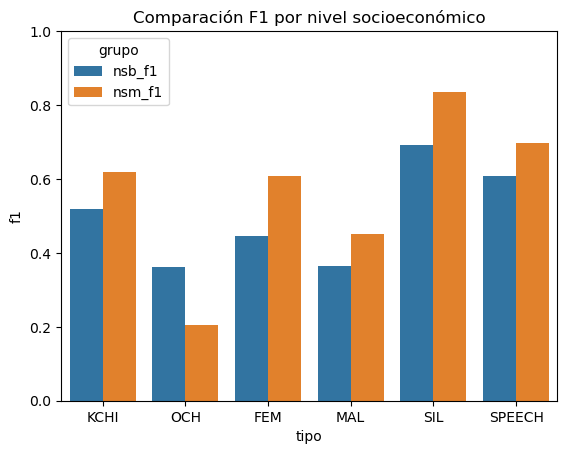

In [122]:
df_plot = df_comp.reset_index().rename(columns={"index": "tipo"})

import seaborn as sns
import matplotlib.pyplot as plt

df_plot_melt = df_plot.melt(
    id_vars="tipo",
    value_vars=["nsb_f1", "nsm_f1"],
    var_name="grupo",
    value_name="f1"
)

sns.barplot(data=df_plot_melt, x="tipo", y="f1", hue="grupo")

plt.title("Comparación F1 por nivel socioeconómico")
plt.ylim(0, 1)
plt.show()

# Parte 6. Multilabel → Single label

In [41]:
def multilabel_to_singlelabel(y_multilabel):
    single_labels = []
    for row in y_multilabel:
        indices = np.where(row == 1)[0]
        if len(indices) == 0:
            single_labels.append(-1)
        else:
            single_labels.append(indices[0])
    return np.array(single_labels)

y_true = multilabel_to_singlelabel(y_true_multi)
y_pred = multilabel_to_singlelabel(y_pred_multi)

valid_indices = y_true != -1
y_true = y_true[valid_indices]
y_pred = y_pred[valid_indices]

## REPORTE SINGLE LABEL

In [42]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report

n_classes = len(labels)

print("\nMatrices one-vs-rest (single-label):")

for i, label in enumerate(labels):
    
    # binarizar: clase i vs resto
    y_true_bin = (y_true == i).astype(int)
    y_pred_bin = (y_pred == i).astype(int)
    
    cm = confusion_matrix(y_true_bin, y_pred_bin)
    
    print(f"\nMatriz para {label}:")
    print(cm)
    
    # --- SOLO ESTO AGREGADO ---
    cm_percent = (cm / cm.sum()) * 100
    print("En %:")
    print(np.round(cm_percent, 1))


Matrices one-vs-rest (single-label):

Matriz para KCHI:
[[5834826  314622]
 [ 176600  489956]]
En %:
[[85.6  4.6]
 [ 2.6  7.2]]

Matriz para OCH:
[[6111532  231548]
 [ 343508  129416]]
En %:
[[89.7  3.4]
 [ 5.   1.9]]

Matriz para FEM:
[[5192686  528884]
 [ 436220  658214]]
En %:
[[76.2  7.8]
 [ 6.4  9.7]]

Matriz para MAL:
[[6241232  198190]
 [ 236816  139766]]
En %:
[[91.6  2.9]
 [ 3.5  2.1]]

Matriz para SIL:
[[2200968  409528]
 [ 989712 3215796]]
En %:
[[32.3  6. ]
 [14.5 47.2]]

Matriz para SPEECH:
[[6816004]]
En %:
[[100.]]


C:\Users\pablo\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:534: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


In [43]:
valid_indices = (y_true != -1) & (y_pred != -1)

y_true = y_true[valid_indices]
y_pred = y_pred[valid_indices]

print("\nReporte single-label (one-vs-rest):")

report = classification_report(
    y_true,
    y_pred,
    labels=list(range(len(labels))),
    target_names=labels,
    zero_division=0,
    output_dict=True
)

import pandas as pd

df_report = pd.DataFrame(report).T

# SOLO ESTO AGREGADO ↓
cols = ['precision', 'recall', 'f1-score']
df_report[cols] = (df_report[cols] * 100).round(1).astype(str) + "%"

print(df_report)


Reporte single-label (one-vs-rest):
             precision recall f1-score       support
KCHI             60.9%  77.9%    68.3%  6.292220e+05
OCH              35.9%  30.8%    33.2%  4.197660e+05
FEM              55.4%  65.7%    60.2%  1.001098e+06
MAL              41.4%  40.7%    41.0%  3.432420e+05
SIL              88.7%  82.0%    85.2%  3.922592e+06
SPEECH            0.0%   0.0%     0.0%  0.000000e+00
accuracy         73.4%  73.4%    73.4%  7.335666e-01
macro avg        47.0%  49.5%    48.0%  6.315920e+06
weighted avg     74.6%  73.4%    73.7%  6.315920e+06


# Parte 7. Matriz de confusión global 

## PRECISIÓN

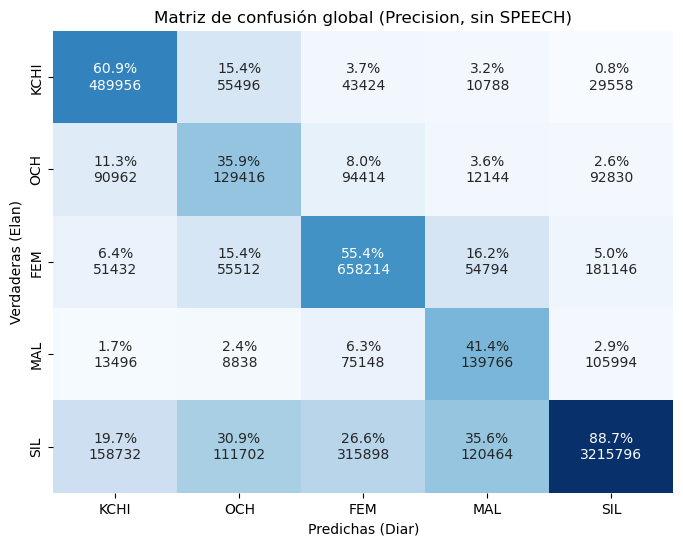

In [55]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

labels_idx = list(range(len(labels)))

# matriz de conteos
cm_counts = confusion_matrix(y_true, y_pred, labels=labels_idx)

# precision: normalizada por columnas
cm_precision = confusion_matrix(y_true, y_pred, labels=labels_idx, normalize="pred")

# sacar SPEECH solo del gráfico
if "SPEECH" in labels:
    idx_speech = labels.index("SPEECH")
    idx_keep = [i for i in range(len(labels)) if i != idx_speech]

    cm_counts_plot = cm_counts[np.ix_(idx_keep, idx_keep)]
    cm_precision_plot = cm_precision[np.ix_(idx_keep, idx_keep)]
    labels_plot = [labels[i] for i in idx_keep]
else:
    cm_counts_plot = cm_counts
    cm_precision_plot = cm_precision
    labels_plot = labels

cm_counts_df = pd.DataFrame(cm_counts_plot, index=labels_plot, columns=labels_plot)
cm_precision_df = pd.DataFrame(cm_precision_plot, index=labels_plot, columns=labels_plot)

annot = (
    (cm_precision_df * 100).round(1).astype(str)
    + "%"
    + "\n"
    + cm_counts_df.astype(int).astype(str)
)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm_precision_df,
    annot=annot,
    fmt="",
    cmap="Blues",
    cbar=False
)

plt.title("Matriz de confusión global (Precision, sin SPEECH)")
plt.ylabel("Verdaderas (Elan)")
plt.xlabel("Predichas (Diar)")

plt.savefig(
    "outputs/final_concats/matriz_confusion_global_precision_sin_speech.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

## RECALL 

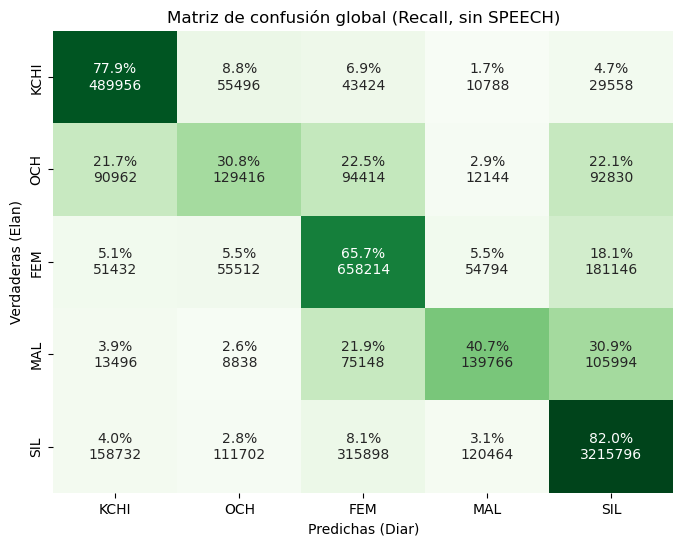

In [56]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

labels_idx = list(range(len(labels)))

# matriz de conteos
cm_counts = confusion_matrix(y_true, y_pred, labels=labels_idx)

# recall: normalizada por filas
cm_recall = confusion_matrix(y_true, y_pred, labels=labels_idx, normalize="true")

# sacar SPEECH solo del gráfico
if "SPEECH" in labels:
    idx_speech = labels.index("SPEECH")
    idx_keep = [i for i in range(len(labels)) if i != idx_speech]

    cm_counts_plot = cm_counts[np.ix_(idx_keep, idx_keep)]
    cm_recall_plot = cm_recall[np.ix_(idx_keep, idx_keep)]
    labels_plot = [labels[i] for i in idx_keep]
else:
    cm_counts_plot = cm_counts
    cm_recall_plot = cm_recall
    labels_plot = labels

cm_counts_df = pd.DataFrame(cm_counts_plot, index=labels_plot, columns=labels_plot)
cm_recall_df = pd.DataFrame(cm_recall_plot, index=labels_plot, columns=labels_plot)

annot = (
    (cm_recall_df * 100).round(1).astype(str)
    + "%"
    + "\n"
    + cm_counts_df.astype(int).astype(str)
)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm_recall_df,
    annot=annot,
    fmt="",
    cmap="Greens",
    cbar=False
)

plt.title("Matriz de confusión global (Recall, sin SPEECH)")
plt.ylabel("Verdaderas (Elan)")
plt.xlabel("Predichas (Diar)")

plt.savefig(
    "outputs/final_concats/matriz_confusion_global_recall_sin_speech.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [58]:
from sklearn.metrics import classification_report

valid_indices = (y_true != -1) & (y_pred != -1)

y_true_f = y_true[valid_indices]
y_pred_f = y_pred[valid_indices]

report_dict = classification_report(
    y_true_f,
    y_pred_f,
    labels=list(range(len(labels))),
    target_names=labels,
    output_dict=True,
    zero_division=0
)

df_metrics = (
    pd.DataFrame(report_dict)
    .T
    .reset_index()
    .rename(columns={
        "index": "Tipo",
        "precision": "Precisión",
        "recall": "Recall",
        "f1-score": "F1-score",
        "support": "Support"
    })
)

df_metrics = df_metrics[df_metrics["Tipo"].isin(labels)].copy()

print(df_metrics)

## ESTO ES SINGLE LABEL

     Tipo  Precisión    Recall  F1-score    Support
0    KCHI   0.608960  0.778670  0.683437   629222.0
1     OCH   0.358529  0.308305  0.331526   419766.0
2     FEM   0.554473  0.657492  0.601604  1001098.0
3     MAL   0.413563  0.407194  0.410354   343242.0
4     SIL   0.887037  0.819814  0.852102  3922592.0
5  SPEECH   0.000000  0.000000  0.000000        0.0


# Parte 8. Gráficos

In [59]:
from sklearn.metrics import classification_report
import pandas as pd

report = classification_report(
    y_true_multi,
    y_pred_multi,
    target_names=labels,
    output_dict=True,
    zero_division=0
)

df_metrics = pd.DataFrame(report).transpose().reset_index()
df_metrics = df_metrics.rename(columns={"index": "Tipo"})

# dejar solo clases, sacar promedios globales
filas_excluir = ["micro avg", "macro avg", "weighted avg", "samples avg"]
df_metrics = df_metrics[~df_metrics["Tipo"].isin(filas_excluir)].copy()

# renombrar columnas
df_metrics = df_metrics.rename(columns={
    "precision": "Precisión",
    "recall": "Recall",
    "f1-score": "F1-score",
    "support": "Support"
})

In [60]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import os

def agregar_etiquetas_barras(ax, formato="{:.1f}%"):
    for container in ax.containers:
        labels = []
        for bar in container:
            h = bar.get_height()
            if pd.isna(h):
                labels.append("")
            else:
                labels.append(formato.format(h * 100))
        ax.bar_label(container, labels=labels, padding=3, fontsize=10)


def plot_metrica(df_metrics, metrica, palette, filename):
    plt.figure(figsize=(8, 6))
    ax = sns.barplot(
        x="Tipo",
        y=metrica,
        data=df_metrics,
        palette=palette
    )

    agregar_etiquetas_barras(ax)

    plt.title(f"{metrica} por Tipo")
    plt.ylim(0, 1.08)
    plt.ylabel(metrica)
    plt.xlabel("Tipo")
    plt.tight_layout()

    os.makedirs(os.path.dirname(filename), exist_ok=True)
    plt.savefig(filename, dpi=300, bbox_inches="tight")
    plt.show()


def plot_metricas_combinadas(df_metrics, filename):
    df_melted = pd.melt(
        df_metrics,
        id_vars=["Tipo"],
        value_vars=["Precisión", "Recall", "F1-score"],
        var_name="Métrica",
        value_name="Valor"
    )

    plt.figure(figsize=(10, 6))
    ax = sns.barplot(
        x="Tipo",
        y="Valor",
        hue="Métrica",
        data=df_melted
    )

    agregar_etiquetas_barras(ax)

    plt.ylim(0, 1.12)
    plt.ylabel("Valor")
    plt.xlabel("Tipo")
    plt.title("Precisión, Recall y F1-score por Tipo")
    plt.legend(title="Métrica")
    plt.tight_layout()

    os.makedirs(os.path.dirname(filename), exist_ok=True)
    plt.savefig(filename, dpi=300, bbox_inches="tight")
    plt.show()

C:\Users\pablo\AppData\Local\Temp\ipykernel_22768\1731587604.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


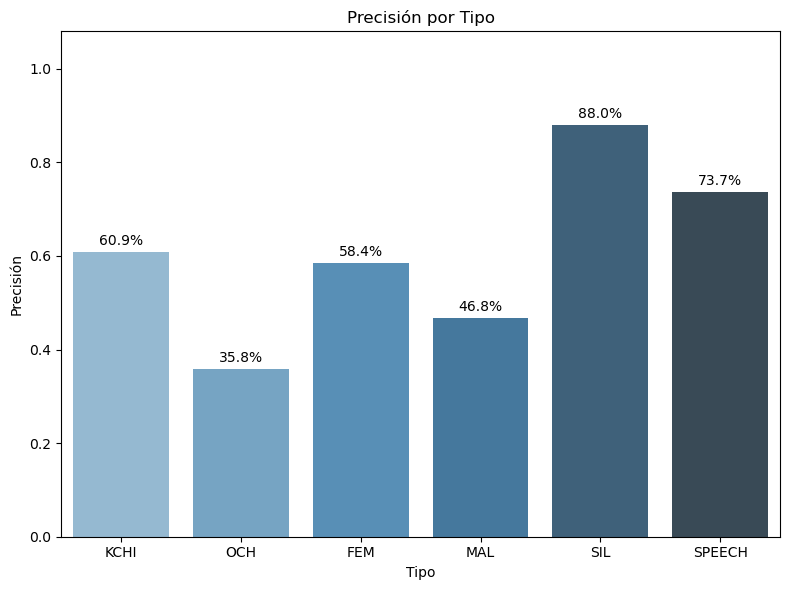

C:\Users\pablo\AppData\Local\Temp\ipykernel_22768\1731587604.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


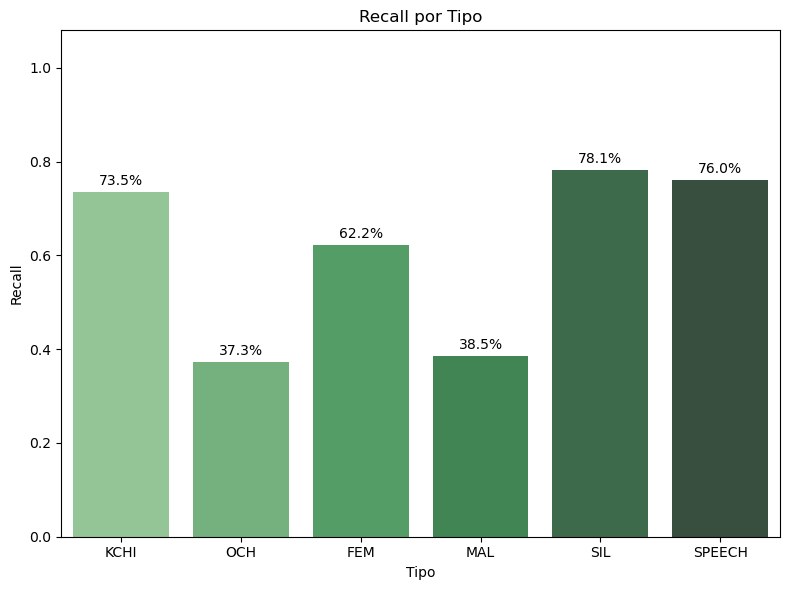

C:\Users\pablo\AppData\Local\Temp\ipykernel_22768\1731587604.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


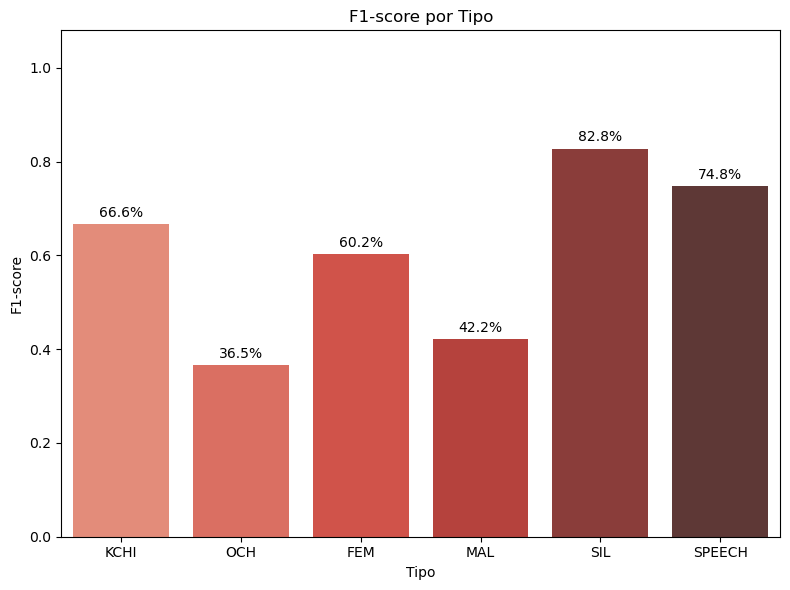

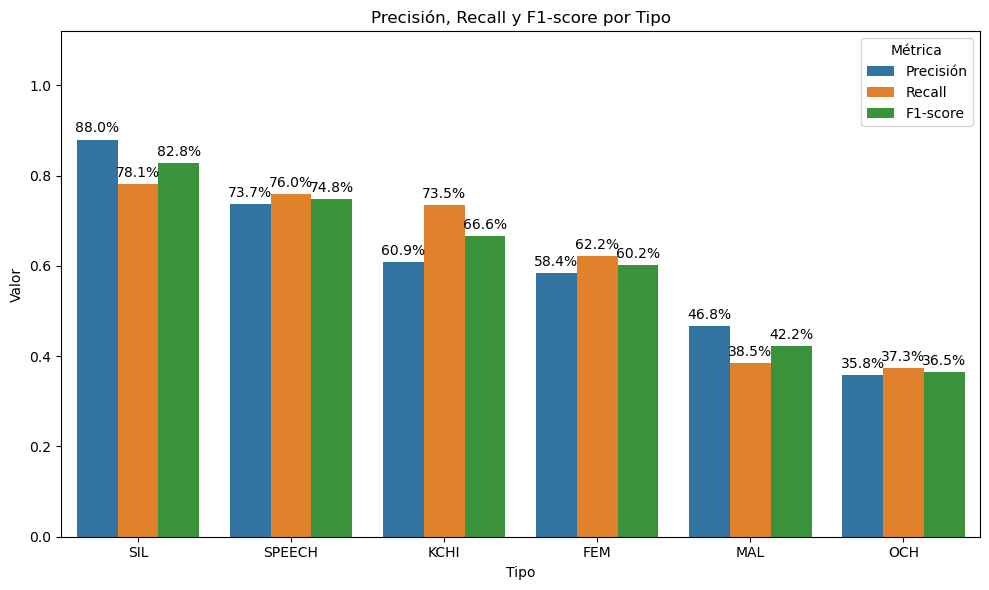

In [61]:
plot_metrica(
    df_metrics,
    "Precisión",
    "Blues_d",
    "outputs/final_concats/precision_multilabel_sin_speech.png"
)

plot_metrica(
    df_metrics,
    "Recall",
    "Greens_d",
    "outputs/final_concats/recall_multilabel_sin_speech.png"
)

plot_metrica(
    df_metrics,
    "F1-score",
    "Reds_d",
    "outputs/final_concats/f1_multilabel_sin_speech.png"
)

df_metrics_ordenado = df_metrics.sort_values("F1-score", ascending=False).copy()

plot_metricas_combinadas(
    df_metrics_ordenado,
    "outputs/final_concats/metricas_combinadas_multilabel_sin_speech.png"
)

# Parte 10. Ranking por chico

In [69]:
tipos_para_ranking = ["FEM", "MAL", "KCHI", "OCH"]

df = pd.read_csv(r"outputs\df_metrics_todos_los_chicos.csv")

# =========================
# 0) Limpieza
# =========================
df["F1-score"] = pd.to_numeric(df["F1-score"], errors="coerce")
df_rank = df[df["Tipo"].isin(tipos_para_ranking)].copy()

# Extraer nombre base del chico desde strings tipo:
# alma-a1-nsb -> alma
# verag-a2-nsm -> verag
def extraer_chico_base(x):
    x = str(x).strip().lower()
    m = re.match(r"^(.*?)-a\d+-ns[mb]$", x)
    if m:
        return m.group(1)
    return x

df_rank["chico"] = df_rank["name"].apply(extraer_chico_base)

# =========================
# 1) Promedio por chico y tipo
# =========================
df_por_tipo = (
    df_rank
    .groupby(["name", "chico", "Tipo"], as_index=False)
    .agg(f1_promedio=("F1-score", "mean"))
)

# =========================
# 2) Pivotear
# =========================
df_pivot = df_por_tipo.pivot(
    index=["name", "chico"],
    columns="Tipo",
    values="f1_promedio"
).reset_index()

df_pivot = df_pivot.rename(columns={
    "FEM": "f1_FEM",
    "MAL": "f1_MAL",
    "KCHI": "f1_KCHI",
    "OCH": "f1_OCH"
})

# Asegurar columnas aunque falte alguna
for col in ["f1_FEM", "f1_MAL", "f1_KCHI", "f1_OCH"]:
    if col not in df_pivot.columns:
        df_pivot[col] = pd.NA

# =========================
# 3) Promedio total
# =========================
columnas_f1 = ["f1_FEM", "f1_MAL", "f1_KCHI", "f1_OCH"]
df_pivot["f1_promedio_total"] = df_pivot[columnas_f1].mean(axis=1)

# =========================
# 4) ns_code
# =========================
meta = (
    df_rank
    .groupby(["name", "chico"], as_index=False)
    .agg(
        ns_code=("ns_code", "first")
    )
)

df_final = df_pivot.merge(meta, on=["name", "chico"], how="left")

# =========================
# 5) Map manual de corpus por chico
# =========================
map_corpus = {
    "alma": "raw_ROS",
    "amparol": "raw_ROS",
    "angelinap": "raw_ROS",
    "bautista": "segunda-vuelta/random",
    "bautistad": "segunda-vuelta/random",
    "biancak": "raw_ROS_HV",
    "brandona": "segunda-vuelta/highVol",
    "camilob": "segunda-vuelta/random",
    "camilop": "raw_ROS_HV",
    "dantec": "raw_ROS",
    "dantep": "raw_ROS_HV",
    "dianag": "raw_ROS_HV",
    "florl": "segunda-vuelta/random",
    "francescam": "raw_ROS_HV",
    "franciscop": "raw_ROS_HV",
    "gaell": "raw_ROS",
    "jeremiasc": "segunda-vuelta/highVol",
    "julietap": "raw_ROS_HV",
    "lisandroh": "raw_ROS",
    "lucasyoelp": "raw_ROS_HV",
    "lucior": "raw_ROS",
    "manuelc": "raw_ROS",
    "ummaq": "raw_ROS",
    "valentina": "segunda-vuelta/highVol",
    "valentinos": "raw_ROS",
    "verag": "raw_ROS_HV",
  
}

df_final["corpus"] = df_final["chico"].map(map_corpus)

# =========================
# 6) Ranking
# =========================
df_final = df_final.sort_values("f1_promedio_total", ascending=False).reset_index(drop=True)
df_final["ranking"] = df_final.index + 1

# =========================
# 7) Orden final
# =========================
df_final = df_final[
    [
        "ranking",
        "name",
        "chico",
        "corpus",
        "ns_code",
        "f1_promedio_total",
        "f1_FEM",
        "f1_MAL",
        "f1_KCHI",
        "f1_OCH"
    ]
]

# =========================
# 8) Revisar faltantes
# =========================
faltan_corpus = df_final[df_final["corpus"].isna()]
if not faltan_corpus.empty:
    print("\nNombres sin corpus asignado:")
    print(faltan_corpus[["name", "chico"]].drop_duplicates().sort_values("chico"))

# Guardar
df_final.to_csv("outputs/ranking_f1_por_label.csv", index=False, encoding="utf-8-sig")



C:\Users\pablo\AppData\Local\Temp\ipykernel_22768\3747874085.py:3: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(r"outputs\df_metrics_todos_los_chicos.csv")


In [70]:
df_final

,ranking,name,chico,corpus,ns_code,f1_promedio_total,f1_FEM,f1_MAL,f1_KCHI,f1_OCH
0,1,alma-a1-nsb,alma,raw_ROS,nsb,0.567843,0.624738,0.464171,0.642668,0.539797
1,2,verag-a2-nsm,verag,raw_ROS_HV,nsm,0.544746,0.819251,0.562983,0.796750,0.000000
2,3,franciscop-a2-nsm,franciscop,raw_ROS_HV,nsm,0.513893,0.744271,0.483493,0.827808,0.000000
3,4,amparol-a1-nsb,amparol,raw_ROS,nsb,0.502191,0.564282,0.426217,0.565517,0.452747
4,5,dantep-a1-nsm,dantep,raw_ROS_HV,nsm,0.492102,0.730624,0.666058,0.571727,0.000000
5,6,dianag-a1-nsb,dianag,raw_ROS_HV,nsb,0.475131,0.673355,0.272314,0.550755,0.404101
6,7,lisandroh-a2-nsm,lisandroh,raw_ROS,nsm,0.469679,0.614277,0.409740,0.495047,0.359653
7,8,lucior-a2-nsm,lucior,raw_ROS,nsm,0.466533,0.679651,0.376634,0.597606,0.212243
8,9,angelinap-a1-nsm,angelinap,raw_ROS,nsm,0.464117,0.573500,0.445049,0.627462,0.210458
9,10,julietap-a1-nsm,julietap,raw_ROS_HV,nsm,0.460615,0.685825,0.326197,0.830437,0.000000
